In [6]:
from pypdf import PdfReader
from pathlib import Path

raw_dir = Path("../data/raw")
pdf_files = list(raw_dir.glob("*.pdf"))
print(f"{len(pdf_files)} PDF trouvés")

for pdf_path in pdf_files:
    reader = PdfReader(pdf_path)
    print(f"\n{pdf_path.name} ({len(reader.pages)} pages)")
    for i, page in enumerate(reader.pages):
        text = page.extract_text()
        text_len = len(text.strip())
        try:
            n_images = len(page.images)
        except Exception as e:
            n_images = f"erreur: {e}"
        print(f"  page {i}: {text_len} caractères, {n_images} image(s)")

7 PDF trouvés

Circulaire_N_26-2012_18092024التغيب غير المشروع عن العمل.pdf (8 pages)
  page 0: 0 caractères, 1 image(s)
  page 1: 0 caractères, 1 image(s)
  page 2: 0 caractères, 1 image(s)
  page 3: 0 caractères, 1 image(s)
  page 4: 0 caractères, 1 image(s)
  page 5: 0 caractères, 1 image(s)
  page 6: 0 caractères, 1 image(s)
  page 7: 0 caractères, 1 image(s)

Decret_marches_publics_n_2_22_431_du_09_03_2023_Fr marchés publics.pdf (93 pages)
  page 0: 214 caractères, 2 image(s)
  page 1: 2198 caractères, 0 image(s)
  page 2: 3102 caractères, 0 image(s)
  page 3: 3128 caractères, 0 image(s)
  page 4: 2826 caractères, 0 image(s)
  page 5: 5517 caractères, 0 image(s)
  page 6: 6139 caractères, 0 image(s)
  page 7: 5718 caractères, 0 image(s)
  page 8: 5912 caractères, 0 image(s)
  page 9: 6472 caractères, 0 image(s)
  page 10: 5327 caractères, 0 image(s)
  page 11: 5992 caractères, 0 image(s)
  page 12: 5476 caractères, 0 image(s)
  page 13: 5654 caractères, 0 image(s)
  page 14: 5918 

In [7]:
def classify_page(page, text_threshold=30):
    text_len = len(page.extract_text().strip())
    if text_len < text_threshold:
        return "scanne"
    return "numerique"

for pdf_path in pdf_files:
    reader = PdfReader(pdf_path)
    results = [classify_page(p) for p in reader.pages]
    n_scan = results.count("scanne")
    n_num = results.count("numerique")
    print(f"{pdf_path.name}: {n_scan} scannée(s), {n_num} numérique(s)")

Circulaire_N_26-2012_18092024التغيب غير المشروع عن العمل.pdf: 8 scannée(s), 0 numérique(s)
Decret_marches_publics_n_2_22_431_du_09_03_2023_Fr marchés publics.pdf: 0 scannée(s), 93 numérique(s)
ExtraitsDahir_N_1-58-008_13092024_Fr sanctions disciplinaires.pdf: 0 scannée(s), 5 numérique(s)
Loi_N_12-81_13092024_Fr_absence_irreguliaire.pdf: 1 scannée(s), 0 numérique(s)
حالات الاستيداع المؤقت.pdf: 1 scannée(s), 0 numérique(s)
قانون الوظيفة العمومية.pdf: 0 scannée(s), 37 numérique(s)
مدة الاستيداع لدواع شخصية.pdf: 1 scannée(s), 0 numérique(s)


In [3]:
from pathlib import Path
import numpy as np
import fitz
from paddleocr import PaddleOCR

ocr_ar = PaddleOCR(
    use_textline_orientation=True,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    lang='ar',
)
ocr_fr = PaddleOCR(use_angle_cls=True, lang='fr')

def render_page_to_array(pdf_path: Path, page_number: int, dpi: int = 200):
    doc = fitz.open(pdf_path)
    page = doc.load_page(page_number)
    pix = page.get_pixmap(dpi=dpi)
    doc.close()
    img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    return img_array

pdf_path = Path("../data/raw/Circulaire_N_26-2012_18092024التغيب غير المشروع عن العمل.pdf")

page_number = 1
img = render_page_to_array(pdf_path, page_number)
result = ocr_ar.predict(img)

print(type(result))
print(result)

Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\T14s\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\T14s\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('arabic_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\T14s\.paddlex\official_models\arabic_PP-OCRv5_mobile_rec`.
C:\Users\T14s\AppData\Local\Temp\ipykernel_20264\2635536965.py:12: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr_fr = PaddleOCR(use_angle_cls=True, lang='fr')
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Us

NotImplementedError: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at ..\paddle\fluid\framework\new_executor\instruction\onednn\onednn_instruction.cc:118)


=== Texte à haute confiance (>0.85) ===
الاستثمار والإضرار بالمصلحة العامة، ويقتضي بالتالي الزجر طبقا للمقتضيات القانونية والتنظيمية
الجاري بها العمل
 تفعيل المقتضيات التشريعية والتنظيمية المتعلقة بالرخص وبالتغيب غير المشروع
يستفيد الموظف العمومي من مجموعة من الرخص وفقا للمقتضيات التشريعية والتنظيمية
الجاري بها العمل، ولاسيما تلك المنصوص عليها في الفصل و من النظام الأساسي العام للوظيفة
العمومية، علما أن المستفيد من هذه الرخص يعتبرفي وضعية القيام بالوظيفة
ويستدعى كل تغيب عن العمل خارج الحالات المنصوص عليها في النصوص التشربعية والتنظيمية
الجاري بها العمل، باعتباره إخلالا بالالتزامات الوظيفية، تفعيل المقتضيات والمساطر القانونية، وعلى
الخصوص منها تلك المتعلقة بترك الوظيفة، والمتابعة التأديبية، والاقتطاع من الأجور، مع ما يقتضيه
ذلك من مراعاة واحترام لحقوق الدفاع طبقا للمساطر الجاري بها العمل
أ ترك الوظيفة
يعتبر في حالة ترك الوظيفة كل موظف تعمد الانقطاع عن عمله خارج الحالات المبررة قانوناء،
الأساسي العام للوظيفة العمومية
ويتعين، في حالة ترك الوظيفة، أن تبادر المصالح المعنية إلى التفعيل الفور

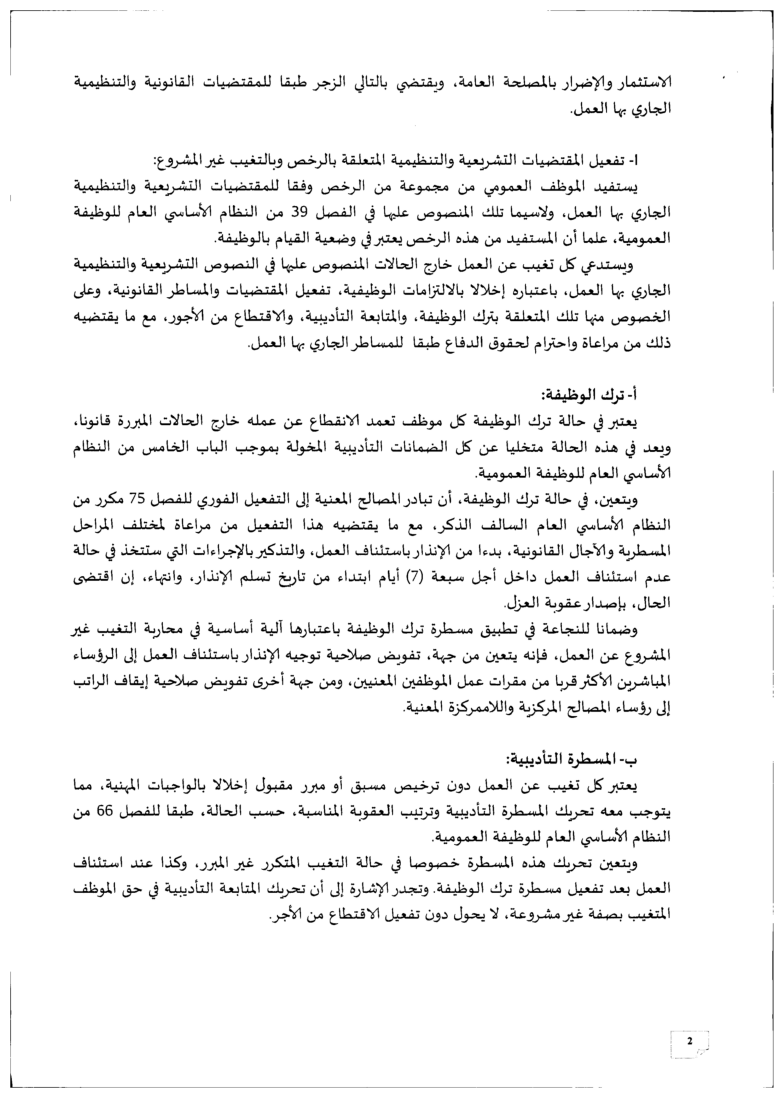

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. Texte propre, trié par position (déjà l'ordre de lecture via _sort_boxes)
page_result = result[0]
texts = page_result['rec_texts']
scores = page_result['rec_scores']

print("=== Texte à haute confiance (>0.85) ===")
clean_text = [t for t, s in zip(texts, scores) if s > 0.85]
print("\n".join(clean_text))

print(f"\n=== {sum(1 for s in scores if s <= 0.85)} lignes sous le seuil, à inspecter ===")
for t, s in zip(texts, scores):
    if s <= 0.85:
        print(f"{s:.2f} — {t!r}")

# 2. Visualiser la page pour identifier ce que sont ces lignes basses
img = Image.fromarray(page_result['doc_preprocessor_res']['output_img'])
plt.figure(figsize=(10, 14))
plt.imshow(img)
plt.axis('off')
plt.show()

In [4]:
from app.repositories.vector_repository import VectorRepository

repo = VectorRepository()
repo.create_table()
print("Migration appliquée.")

Migration appliquée.


In [ ]:
from pathlib import Path
from app.ingestion.scan_pipeline import process_document

process_document(
    pdf_path=Path("data/raw/حالات الاستيداع المؤقت.pdf"),
    lang_code="ar",
    lang_prompt="arabic",
)

ModuleNotFoundError: No module named 'extract'